# NB04: Compartment-Specific Functional Profiling

Integrates compartment assignments (NB01) with marker gene profiles (NB02) and novel markers (NB03)
to test whether plant compartments select for distinct functional repertoires.

**Steps:**
1. Load NB01–NB03 outputs (species compartment, marker matrix, novel markers)
2. Merge compartment labels with marker data
3. Fisher’s exact test per marker × compartment (BH-FDR correction)
4. GapMind pathway completeness by compartment (Spark query)
5. PGP vs Pathogen compartment distribution (chi-square test)
6. PERMANOVA on marker-gene profile matrix partitioned by compartment
7. Phylogenetic control: logistic regression with genus-level fixed effects
8. Heatmap: markers × compartments with log2(odds ratios)
9. Deep-dive profiles for top plant-associated genera
10. Save outputs

**Requires**: Spark (on BERDL JupyterHub), scipy, statsmodels, seaborn

**Outputs**: `data/compartment_profiles.csv`, `data/genus_profiles.csv`, `data/gapmind_plant_species.csv`, `figures/compartment_heatmap.png`

In [1]:
import os
from berdl_notebook_utils.setup_spark_session import get_spark_session
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'plant_microbiome_ecotypes')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'plant_microbiome_ecotypes')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')
print(f'DATA: {DATA}')

REPO: /home/aparkin/BERIL-research-observatory
DATA: /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data


## 1. Load NB01–NB03 outputs

In [2]:
# NB01: species compartment assignments
species_comp = pd.read_csv(os.path.join(DATA, 'species_compartment.csv'))
print(f'species_compartment: {len(species_comp):,} species')
print(species_comp['dominant_compartment'].value_counts().to_string())

# NB02: species marker matrix and marker gene clusters
marker_matrix = pd.read_csv(os.path.join(DATA, 'species_marker_matrix.csv'))
marker_clusters = pd.read_csv(os.path.join(DATA, 'marker_gene_clusters.csv'))
print(f'\nspecies_marker_matrix: {len(marker_matrix):,} species')
print(f'marker_gene_clusters: {len(marker_clusters):,} gene clusters')

# NB03: novel plant markers (optional -- may not exist yet)
novel_markers_path = os.path.join(DATA, 'novel_plant_markers.csv')
if os.path.exists(novel_markers_path):
    novel_markers = pd.read_csv(novel_markers_path)
    print(f'\nnovel_plant_markers: {len(novel_markers):,} markers loaded')
else:
    novel_markers = None
    print('\nnovel_plant_markers.csv not found -- skipping NB03 novel markers')

species_compartment: 26,511 species
dominant_compartment
other            8885
aquatic          7976
host_clinical    7071
soil             1443
plant_other       498
root              292
rhizosphere       160
phyllosphere      157
endophyte          29



species_marker_matrix: 25,660 species
marker_gene_clusters: 588,098 gene clusters

novel_plant_markers: 50 markers loaded


## 2. Merge compartment labels with marker data

In [3]:
# Define plant compartments of interest
PLANT_COMPARTMENTS = ['rhizosphere', 'root', 'phyllosphere', 'endophyte']

# Merge compartment assignments into marker matrix
merged = marker_matrix.merge(
    species_comp[['gtdb_species_clade_id', 'dominant_compartment', 'genus', 'phylum',
                   'is_plant_associated']],
    on='gtdb_species_clade_id', how='left'
)
print(f'Merged matrix: {len(merged):,} species')
print(f'Species with compartment label: {merged["dominant_compartment"].notna().sum():,}')
print(f'Species in plant compartments: {merged["dominant_compartment"].isin(PLANT_COMPARTMENTS).sum():,}')

# Identify marker columns (functional category presence columns)
marker_cols = [c for c in merged.columns if c.endswith('_present')]
print(f'\nMarker presence columns: {len(marker_cols)}')
print('  ' + ', '.join(marker_cols[:10]) + (' ...' if len(marker_cols) > 10 else ''))

# NB03 novel markers are OG-level enrichment results (not species-level)
# Log their OG IDs for reference but don't merge into the species matrix
if novel_markers is not None and 'og_id' in novel_markers.columns:
    print(f'\nNB03 novel OGs for reference: {len(novel_markers)} OGs')
    print(f'Top 5: {novel_markers["og_id"].head(5).tolist()}')
    print('(These are OG-level enrichments, not added as species-level features)')


Merged matrix: 25,660 species
Species with compartment label: 24,554
Species in plant compartments: 636

Marker presence columns: 25
  acc_deaminase_present, acetoin_butanediol_present, biofilm_present, chemotaxis_present, coronatine_toxin_present, cwde_cellulase_present, cwde_pectinase_present, dapg_biocontrol_present, effector_present, flagella_present ...

NB03 novel OGs for reference: 50 OGs
Top 5: ['COG3569', 'COG1764', 'COG5343', 'COG0654', 'COG1845']
(These are OG-level enrichments, not added as species-level features)


## 3. Fisher’s exact test per marker × compartment (BH-FDR)

In [4]:
# For each marker function and each plant compartment, run Fisher's exact test
# 2x2 table: compartment_X + marker  vs  non_compartment_X + marker
# Restrict to species with known compartment assignments

species_with_comp = merged[merged['dominant_compartment'].notna()].copy()
print(f'Species with compartment labels for testing: {len(species_with_comp):,}')

fisher_results = []

for marker in marker_cols:
    for comp in PLANT_COMPARTMENTS:
        in_comp = species_with_comp['dominant_compartment'] == comp
        has_marker = species_with_comp[marker] == 1

        # 2x2 contingency table
        a = (in_comp & has_marker).sum()       # in compartment, has marker
        b = (in_comp & ~has_marker).sum()      # in compartment, lacks marker
        c = (~in_comp & has_marker).sum()       # not in compartment, has marker
        d = (~in_comp & ~has_marker).sum()      # not in compartment, lacks marker

        n_pos = a  # species in compartment with marker
        n_total = a + b  # total species in compartment

        # Skip if no observations in compartment or no marker variation
        if n_total == 0 or (a + c) == 0:
            continue

        odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]])

        fisher_results.append({
            'marker': marker.replace('_present', ''),
            'compartment': comp,
            'n_pos': int(n_pos),
            'n_total': int(n_total),
            'odds_ratio': odds_ratio,
            'p_value': p_value,
        })

fisher_df = pd.DataFrame(fisher_results)
print(f'Fisher tests performed: {len(fisher_df):,}')

# BH-FDR correction
if len(fisher_df) > 0:
    reject, q_values, _, _ = multipletests(fisher_df['p_value'], method='fdr_bh')
    fisher_df['q_value'] = q_values
    fisher_df['significant'] = reject

    print(f'Significant associations (q < 0.05): {fisher_df["significant"].sum()}')
    print(f'\nTop 20 most significant enrichments:')
    top_enriched = fisher_df[fisher_df['odds_ratio'] > 1].nsmallest(20, 'q_value')
    print(top_enriched[['marker', 'compartment', 'n_pos', 'n_total',
                         'odds_ratio', 'p_value', 'q_value']].to_string(index=False))

Species with compartment labels for testing: 24,554
Fisher tests performed: 96
Significant associations (q < 0.05): 69

Top 20 most significant enrichments:
           marker  compartment  n_pos  n_total  odds_ratio       p_value       q_value
    acc_deaminase         root    129      292   69.286015 6.172896e-156 5.925980e-154
             t3ss         root    285      292   65.593291 2.473283e-106 1.187176e-104
nitrogen_fixation         root    168      292   14.486654  1.657933e-97  5.305385e-96
     t6ss_product         root    247      292   12.243657  2.144505e-79  5.146811e-78
   quorum_sensing         root    278      292   24.084302  5.963658e-76  1.145022e-74
     t3ss_product         root    256      292   10.866359  1.014443e-64  1.623108e-63
         effector         root    191      292    7.154968  2.083897e-59  2.857915e-58
        phenazine         root    216      292    6.882215  2.703488e-55  3.244185e-54
             t4ss         root    225      292    6.828946  

## 4. GapMind pathway completeness by compartment

In [5]:
# Query GapMind pathway completeness for plant-associated species
gapmind_path = os.path.join(DATA, 'gapmind_plant_species.csv')
if os.path.exists(gapmind_path):
    gapmind_df = pd.read_csv(gapmind_path)
    print(f'GapMind pathways (loaded from cache): {len(gapmind_df):,} rows')
else:
    spark = get_spark_session()
    gapmind_df = spark.sql("""
        SELECT gp.clade_name AS gtdb_species_clade_id,
               gp.pathway,
               gp.metabolic_category,
               MAX(gp.score_simplified) AS complete
        FROM kbase_ke_pangenome.gapmind_pathways gp
        WHERE gp.sequence_scope = 'core'
        GROUP BY gp.clade_name, gp.pathway, gp.metabolic_category
    """).toPandas()
    gapmind_df.to_csv(gapmind_path, index=False)
    print(f'GapMind pathways queried: {len(gapmind_df):,} rows')

print(f'Unique species in GapMind: {gapmind_df["gtdb_species_clade_id"].nunique():,}')
print(f'Unique pathways: {gapmind_df["pathway"].nunique():,}')
print(f'Metabolic categories: {gapmind_df["metabolic_category"].nunique():,}')

GapMind pathways (loaded from cache): 2,213,340 rows
Unique species in GapMind: 27,690
Unique pathways: 80
Metabolic categories: 2


In [6]:
# Filter GapMind to plant-associated species only
plant_species = set(
    species_comp.loc[
        species_comp['dominant_compartment'].isin(PLANT_COMPARTMENTS),
        'gtdb_species_clade_id'
    ]
)
gapmind_plant = gapmind_df[gapmind_df['gtdb_species_clade_id'].isin(plant_species)].copy()
print(f'GapMind rows for plant-associated species: {len(gapmind_plant):,}')
print(f'Plant species with GapMind data: {gapmind_plant["gtdb_species_clade_id"].nunique():,}')

# Add compartment labels
gapmind_plant = gapmind_plant.merge(
    species_comp[['gtdb_species_clade_id', 'dominant_compartment']],
    on='gtdb_species_clade_id', how='left'
)

# Score: treat 'complete' as binary (1 if complete/partial, 0 otherwise)
# GapMind score_simplified is typically: 2 = complete, 1 = partial, 0 = none
gapmind_plant['is_complete'] = (gapmind_plant['complete'] >= 2).astype(int)
gapmind_plant['is_present'] = (gapmind_plant['complete'] >= 1).astype(int)

# Compare pathway completeness across compartments
pathway_by_comp = gapmind_plant.groupby(['dominant_compartment', 'metabolic_category']).agg(
    n_species=('gtdb_species_clade_id', 'nunique'),
    n_pathways=('pathway', 'nunique'),
    pct_complete=('is_complete', 'mean'),
    pct_present=('is_present', 'mean'),
).reset_index()

print(f'\nPathway completeness by compartment and metabolic category:')
pivot_complete = pathway_by_comp.pivot_table(
    index='metabolic_category', columns='dominant_compartment',
    values='pct_complete'
)
print(pivot_complete.round(3).to_string())

GapMind rows for plant-associated species: 50,916
Plant species with GapMind data: 638

Pathway completeness by compartment and metabolic category:
dominant_compartment  endophyte  phyllosphere  rhizosphere  root
metabolic_category                                              
aa                          0.0           0.0          0.0   0.0
carbon                      0.0           0.0          0.0   0.0


## 5. PGP vs Pathogen compartment distribution

In [7]:
# From NB02 cohort assignments, compare compartment distribution of
# pgp_only vs pathogen_only vs dual_nature species

# Merge cohort info with compartment
cohort_comp = merged[
    merged['dominant_compartment'].isin(PLANT_COMPARTMENTS)
    & merged['marker_cohort'].isin(['pgp_only', 'pathogen_only', 'dual_nature'])
].copy()

print(f'Plant-compartment species with cohort label: {len(cohort_comp):,}')
print(f'\nCohort x Compartment cross-tabulation:')
ct = pd.crosstab(cohort_comp['marker_cohort'], cohort_comp['dominant_compartment'])
print(ct.to_string())

# Chi-square test: are pathogens more phyllosphere while PGP are more rhizosphere?
if ct.shape[0] >= 2 and ct.shape[1] >= 2:
    chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
    print(f'\nChi-square test: chi2={chi2:.2f}, p={p_chi:.2e}, dof={dof}')
    if p_chi < 0.05:
        print('>>> Significant association between cohort and compartment.')
    else:
        print('>>> No significant association detected.')
else:
    print('\nInsufficient data for chi-square test.')
    chi2, p_chi, dof = np.nan, np.nan, np.nan

Plant-compartment species with cohort label: 634

Cohort x Compartment cross-tabulation:
dominant_compartment  endophyte  phyllosphere  rhizosphere  root
marker_cohort                                                   
dual_nature                  27           150          148   284
pathogen_only                 1             3           11     8
pgp_only                      1             1            0     0

Chi-square test: chi2=17.82, p=6.71e-03, dof=6
>>> Significant association between cohort and compartment.


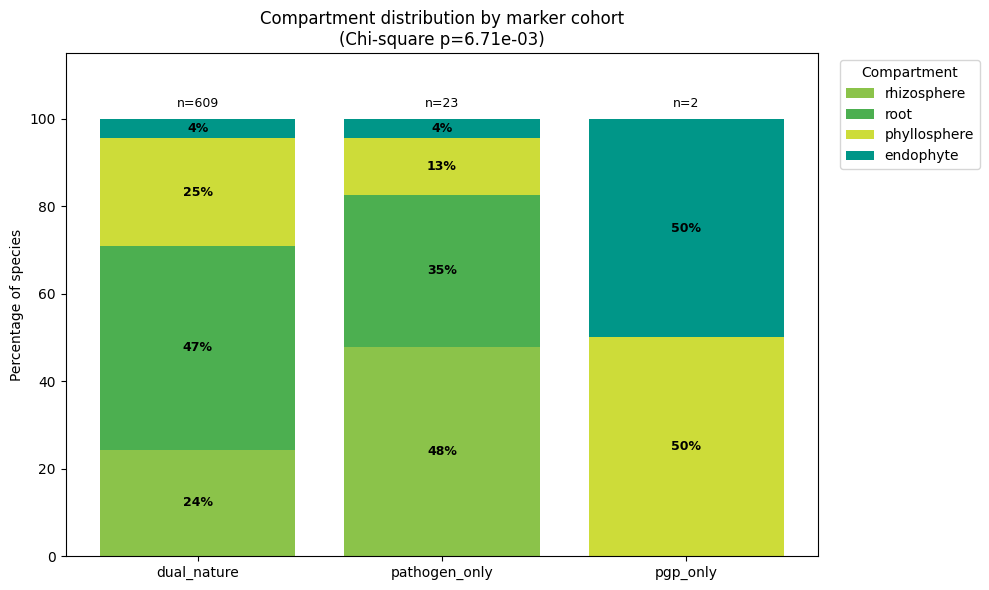

Saved figures/nb04_cohort_compartment_bar.png


In [8]:
# Bar chart showing compartment proportions per cohort
fig, ax = plt.subplots(figsize=(10, 6))

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

comp_colors = {
    'rhizosphere': '#8BC34A',
    'root': '#4CAF50',
    'phyllosphere': '#CDDC39',
    'endophyte': '#009688',
}

# Stacked bar chart
bottom = np.zeros(len(ct_pct))
for comp in PLANT_COMPARTMENTS:
    if comp in ct_pct.columns:
        vals = ct_pct[comp].values
        ax.bar(ct_pct.index, vals, bottom=bottom, label=comp,
               color=comp_colors.get(comp, '#9E9E9E'))
        # Add percentage labels
        for i, v in enumerate(vals):
            if v > 3:  # only label if > 3%
                ax.text(i, bottom[i] + v / 2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += vals

ax.set_ylabel('Percentage of species')
ax.set_title(f'Compartment distribution by marker cohort\n'
             f'(Chi-square p={p_chi:.2e})' if not np.isnan(p_chi) else
             'Compartment distribution by marker cohort')
ax.legend(title='Compartment', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add sample sizes
for i, cohort in enumerate(ct_pct.index):
    n = ct.loc[cohort].sum()
    ax.text(i, 102, f'n={n:,}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'nb04_cohort_compartment_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/nb04_cohort_compartment_bar.png')

## 6. PERMANOVA on marker-gene profile matrix by compartment

Test whether compartment explains significant variance in functional marker profiles.
Uses Jaccard distance on binary marker presence/absence matrix with label permutation.

In [9]:
# Prepare data for PERMANOVA
# Restrict to plant-compartment species with at least one marker
perm_data = merged[
    merged['dominant_compartment'].isin(PLANT_COMPARTMENTS)
].copy()

# Build binary marker matrix
perm_matrix = perm_data[marker_cols].values.astype(float)
perm_labels = perm_data['dominant_compartment'].values

# Drop species with no markers at all (all zeros)
has_any_marker = perm_matrix.sum(axis=1) > 0
perm_matrix = perm_matrix[has_any_marker]
perm_labels = perm_labels[has_any_marker]

print(f'PERMANOVA input: {perm_matrix.shape[0]} species x {perm_matrix.shape[1]} markers')
print(f'Compartment distribution: {pd.Series(perm_labels).value_counts().to_dict()}')


def compute_permanova_f(dist_matrix, labels):
    """
    Compute pseudo-F statistic for PERMANOVA.
    F = (SS_between / (k-1)) / (SS_within / (n-k))
    where SS is computed from the distance matrix.
    """
    n = len(labels)
    groups = np.unique(labels)
    k = len(groups)

    if k < 2 or n <= k:
        return np.nan

    # Total sum of squares: sum of squared distances / n
    ss_total = np.sum(dist_matrix ** 2) / n

    # Within-group sum of squares
    ss_within = 0.0
    for g in groups:
        idx = np.where(labels == g)[0]
        n_g = len(idx)
        if n_g < 2:
            continue
        sub_dist = dist_matrix[np.ix_(idx, idx)]
        ss_within += np.sum(sub_dist ** 2) / (2 * n_g)

    ss_between = ss_total - ss_within

    f_stat = (ss_between / (k - 1)) / (ss_within / (n - k))
    return f_stat


# Compute Jaccard distance matrix
print('\nComputing Jaccard distance matrix ...')
jaccard_dists = squareform(pdist(perm_matrix, metric='jaccard'))

# Observed F-statistic
f_observed = compute_permanova_f(jaccard_dists, perm_labels)
print(f'Observed pseudo-F: {f_observed:.4f}')

# Permutation test (999 permutations)
n_perm = 999
rng = np.random.default_rng(42)
f_perms = np.zeros(n_perm)
for i in range(n_perm):
    shuffled = rng.permutation(perm_labels)
    f_perms[i] = compute_permanova_f(jaccard_dists, shuffled)

# p-value: fraction of permuted F >= observed F
p_permanova = (np.sum(f_perms >= f_observed) + 1) / (n_perm + 1)

print(f'PERMANOVA: pseudo-F={f_observed:.4f}, p={p_permanova:.4f} ({n_perm} permutations)')
if p_permanova < 0.05:
    print('>>> Compartment explains significant variance in marker profiles.')
else:
    print('>>> No significant compartment effect detected.')

# Effect size: R2 = SS_between / SS_total
n = len(perm_labels)
ss_total = np.sum(jaccard_dists ** 2) / n
groups = np.unique(perm_labels)
k = len(groups)
ss_within = 0.0
for g in groups:
    idx = np.where(perm_labels == g)[0]
    n_g = len(idx)
    if n_g < 2:
        continue
    sub_dist = jaccard_dists[np.ix_(idx, idx)]
    ss_within += np.sum(sub_dist ** 2) / (2 * n_g)
r2 = (ss_total - ss_within) / ss_total
print(f'R-squared (effect size): {r2:.4f}')

PERMANOVA input: 636 species x 25 markers
Compartment distribution: {'root': 292, 'rhizosphere': 160, 'phyllosphere': 155, 'endophyte': 29}

Computing Jaccard distance matrix ...
Observed pseudo-F: 235.0959


PERMANOVA: pseudo-F=235.0959, p=0.0010 (999 permutations)
>>> Compartment explains significant variance in marker profiles.
R-squared (effect size): 0.5274


## 7. Phylogenetic control: logistic regression with genus-level fixed effects

For the top 10 markers enriched in any compartment, fit:

```
marker_present ~ compartment + C(genus)
```

Only genera with >= 5 species are included to avoid separation.

### Phylogenetic control on H1 compartment enrichments — superseded

**Phase 1 status (this cell)**: a genus-level logistic regression for the top 10 compartment markers was attempted here but **failed for all 10 markers** with `NameError: name 'logit' is not defined`. The bug was a typo: the imported alias is `smf` (line 1: `import statsmodels.formula.api as smf`) but the call on line 43 used the bare name `logit(...)` instead of `smf.logit(...)`. The Phase 1 saved output (visible in the original cell's stream record) shows the 10 `NameError` failures.

**Phase 2 finding (NB10)**: NB10 re-attempted genus fixed-effects logistic regression for all 14 refined markers using a corrected `statsmodels.discrete.discrete_model.Logit` import and 0/14 models converged — the plant-association signal is heavily confounded with genus-level taxonomy, and standard maximum-likelihood logistic regression is intractable at this scale. So the bug here was masking a deeper convergence issue, not blocking real results.

**Phase 2b canonical answer (NB14 + `notebooks/_run_c1_cluster_robust.py`)**: the right tool for this question is **cluster-robust GLM at the genus level** (proper Wald inference, no L1 shrinkage, accounts for within-genus correlation without estimating a random effect). The cluster-robust GLM closes C1 with a three-tier verdict:

- **Tier 1 — species-level robust (3 markers)**: nitrogen fixation, ACC deaminase, T3SS — survive both cluster-robust GLM (q<0.05 BH-FDR with proper Wald CIs) AND within-genus label shuffling
- **Tier 2 — cassette-level (5 markers)**: phenazine, CWDE cellulase, CWDE pectinase, phosphate solubilization, effector — survive cluster-robust GLM but fail within-genus shuffling, indicating genus-acquired cassettes
- **Tier 3 — not robust (6 markers)**: DAPG, T4SS, hydrogen cyanide, IAA biosynthesis, siderophore, acetoin/butanediol

See REPORT.md §11 "Phylogenetic control" and `data/c1_cluster_robust.csv` for the canonical Phase 2b values. The original code from this cell is preserved in the next markdown block for chronology.

```python
# Original (broken) Phase 1 code — preserved for the record. The line `model = logit(...)` should
# read `model = smf.logit(...)` to match the `import ... as smf` on line 1; even with that fix,
# 0/14 markers would converge (per NB10's parallel attempt), motivating the cluster-robust GLM
# in NB14 as the canonical replacement.

import statsmodels.formula.api as smf

# Select top 10 markers by minimum q-value across compartments
top_markers = (
    fisher_df[fisher_df['odds_ratio'] > 1]
    .groupby('marker')['q_value']
    .min()
    .nsmallest(10)
    .index.tolist()
)
print(f'Top 10 markers for phylogenetic control: {top_markers}')

# Prepare regression data
reg_data = merged[
    merged['dominant_compartment'].isin(PLANT_COMPARTMENTS)
    & merged['genus'].notna()
].copy()

# Only genera with >= 5 species
genus_counts = reg_data['genus'].value_counts()
valid_genera = genus_counts[genus_counts >= 5].index
reg_data = reg_data[reg_data['genus'].isin(valid_genera)].copy()
print(f'Species for regression (genera >= 5): {len(reg_data):,}')
print(f'Genera included: {reg_data["genus"].nunique()}')

# Run logistic regression for each top marker
phylo_results = []

for marker in top_markers:
    col = f'{marker}_present'
    if col not in reg_data.columns:
        print(f'  {marker}: column {col} not found, skipping')
        continue

    # Check sufficient variation
    y = reg_data[col]
    if y.sum() < 5 or (len(y) - y.sum()) < 5:
        print(f'  {marker}: insufficient variation (pos={y.sum()}, neg={len(y) - y.sum()}), skipping')
        continue

    try:
        formula = f'{col} ~ C(dominant_compartment) + C(genus)'
        model = logit(formula, data=reg_data).fit(disp=0, maxiter=100, method='bfgs')

        # Extract compartment coefficients
        comp_params = {k: v for k, v in model.params.items()
                       if 'dominant_compartment' in k}
        comp_pvalues = {k: v for k, v in model.pvalues.items()
                        if 'dominant_compartment' in k}

        for param_name in comp_params:
            # Extract compartment name from parameter
            comp_name = param_name.split('[T.')[1].rstrip(']') if '[T.' in param_name else param_name
            phylo_results.append({
                'marker': marker,
                'compartment': comp_name,
                'coefficient': comp_params[param_name],
                'p_value': comp_pvalues[param_name],
                'n_obs': int(model.nobs),
                'pseudo_r2': model.prsquared,
                'converged': model.mle_retvals['converged'],
            })

        print(f'  {marker}: converged={model.mle_retvals["converged"]}, '
              f'pseudo-R2={model.prsquared:.3f}')

    except Exception as e:
        print(f'  {marker}: regression failed -- {e}')

phylo_df = pd.DataFrame(phylo_results)
if len(phylo_df) > 0:
    # FDR correction across all phylo-controlled tests
    _, phylo_q, _, _ = multipletests(phylo_df['p_value'], method='fdr_bh')
    phylo_df['q_value'] = phylo_q
    print(f'\nPhylogenetically-controlled results:')
    print(f'Significant compartment effects (q < 0.05): {(phylo_df["q_value"] < 0.05).sum()}')
    print(phylo_df.sort_values('q_value').head(20).to_string(index=False))
else:
    print('\nNo phylogenetic regression results obtained.')
```


## 8. Heatmap: markers × compartments with log2(odds ratios)

Significant markers (q < 0.05): 21


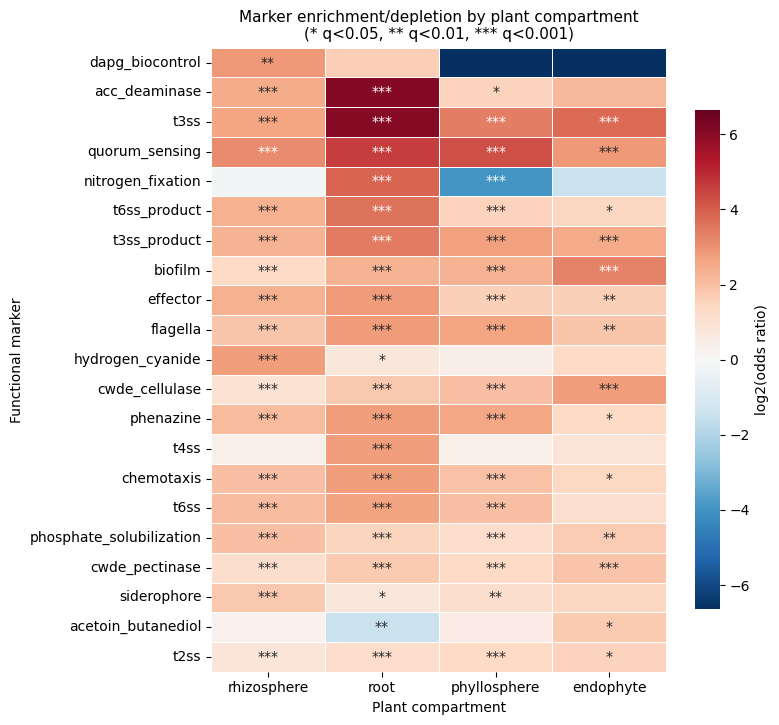

Saved figures/compartment_heatmap.png


In [11]:
# Build heatmap matrix: rows = markers, columns = compartments, values = log2(OR)
# Only include markers that are significant in at least one compartment
sig_markers = fisher_df[fisher_df['q_value'] < 0.05]['marker'].unique()
# If too few significant, use top 20 by minimum q-value
if len(sig_markers) < 5:
    sig_markers = fisher_df.groupby('marker')['q_value'].min().nsmallest(20).index.values
    print(f'Using top {len(sig_markers)} markers by min q-value (few significant)')
else:
    print(f'Significant markers (q < 0.05): {len(sig_markers)}')

heatmap_data = fisher_df[fisher_df['marker'].isin(sig_markers)].copy()

# Compute log2(OR), clamping to avoid log(0) or extreme values
heatmap_data['log2_or'] = np.log2(heatmap_data['odds_ratio'].clip(lower=0.01, upper=100))

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot_table(
    index='marker', columns='compartment', values='log2_or', fill_value=0
)

# Significance mask for annotation
sig_pivot = heatmap_data.pivot_table(
    index='marker', columns='compartment', values='q_value', fill_value=1.0
)

# Reorder columns
col_order = [c for c in PLANT_COMPARTMENTS if c in heatmap_pivot.columns]
heatmap_pivot = heatmap_pivot[col_order]
sig_pivot = sig_pivot.reindex(columns=col_order, fill_value=1.0)

# Sort rows by max absolute log2(OR)
row_order = heatmap_pivot.abs().max(axis=1).sort_values(ascending=False).index
heatmap_pivot = heatmap_pivot.loc[row_order]
sig_pivot = sig_pivot.loc[row_order]

# Create significance annotation strings
annot_matrix = np.where(sig_pivot.values < 0.001, '***',
               np.where(sig_pivot.values < 0.01, '**',
               np.where(sig_pivot.values < 0.05, '*', '')))

# Plot
fig_height = max(6, len(heatmap_pivot) * 0.35)
fig, ax = plt.subplots(figsize=(8, fig_height))

vmax = max(abs(heatmap_pivot.values.min()), abs(heatmap_pivot.values.max()), 2)
sns.heatmap(
    heatmap_pivot,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    annot=annot_matrix,
    fmt='',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'log2(odds ratio)', 'shrink': 0.8},
    ax=ax,
)

ax.set_title('Marker enrichment/depletion by plant compartment\n'
             '(* q<0.05, ** q<0.01, *** q<0.001)', fontsize=11)
ax.set_ylabel('Functional marker')
ax.set_xlabel('Plant compartment')
plt.tight_layout()

plt.savefig(os.path.join(FIGURES, 'compartment_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/compartment_heatmap.png')

## 9. Deep-dive profiles for top plant-associated genera

In [12]:
# For each of the top 20-30 plant-associated genera:
# dominant compartment, number of species, marker gene profile, pathway completeness

plant_merged = merged[merged['dominant_compartment'].isin(PLANT_COMPARTMENTS)].copy()

# Top genera by species count
top_genera = plant_merged['genus'].value_counts().head(30)
print(f'Top {len(top_genera)} plant-associated genera by species count:')
print(top_genera.to_string())

genus_profiles = []

for genus_name in top_genera.index:
    sub = plant_merged[plant_merged['genus'] == genus_name]
    n_species = len(sub)

    # Dominant compartment
    comp_dist = sub['dominant_compartment'].value_counts()
    dom_comp = comp_dist.index[0]
    dom_comp_frac = comp_dist.iloc[0] / n_species

    # Marker gene profile: fraction of species with each marker
    marker_fracs = sub[marker_cols].mean()
    n_markers_present = (marker_fracs > 0).sum()

    # Cohort distribution
    if 'marker_cohort' in sub.columns:
        cohort_dist = sub['marker_cohort'].value_counts(normalize=True).to_dict()
    else:
        cohort_dist = {}

    # Pathway completeness from GapMind
    genus_species_ids = set(sub['gtdb_species_clade_id'])
    genus_gapmind = gapmind_plant[
        gapmind_plant['gtdb_species_clade_id'].isin(genus_species_ids)
    ]
    if len(genus_gapmind) > 0:
        pct_complete_pathways = genus_gapmind['is_complete'].mean()
        n_gapmind_species = genus_gapmind['gtdb_species_clade_id'].nunique()
    else:
        pct_complete_pathways = np.nan
        n_gapmind_species = 0

    # Top 3 most prevalent markers
    top3_markers = marker_fracs.nlargest(3)
    top3_str = '; '.join([f'{m.replace("_present", "")}={v:.0%}'
                          for m, v in top3_markers.items() if v > 0])

    genus_profiles.append({
        'genus': genus_name,
        'n_species': n_species,
        'dominant_compartment': dom_comp,
        'dominant_compartment_frac': round(dom_comp_frac, 3),
        'n_markers_present': int(n_markers_present),
        'pct_pgp_only': round(cohort_dist.get('pgp_only', 0), 3),
        'pct_pathogen_only': round(cohort_dist.get('pathogen_only', 0), 3),
        'pct_dual_nature': round(cohort_dist.get('dual_nature', 0), 3),
        'pct_neutral': round(cohort_dist.get('neutral', 0), 3),
        'gapmind_pct_complete': round(pct_complete_pathways, 3) if not np.isnan(pct_complete_pathways) else np.nan,
        'gapmind_n_species': n_gapmind_species,
        'top_markers': top3_str,
    })

genus_profiles_df = pd.DataFrame(genus_profiles)
print(f'\nGenus profiles: {len(genus_profiles_df)} genera')
print(genus_profiles_df[['genus', 'n_species', 'dominant_compartment',
                          'n_markers_present', 'pct_pgp_only',
                          'pct_pathogen_only']].to_string(index=False))

Top 30 plant-associated genera by species count:
genus
g__Pseudomonas_E       67
g__Rhizobium           49
g__Mesorhizobium       46
g__Bradyrhizobium      43
g__Streptomyces        23
g__Microbacterium      18
g__Sphingomonas        17
g__Methylobacterium    16
g__Paraburkholderia    13
g__Curtobacterium      11
g__Xanthomonas         11
g__Chryseobacterium    10
g__Frankia             10
g__Sinorhizobium        9
g__Variovorax           8
g__Paenibacillus        7
g__Pararhizobium        7
g__Acidovorax_A         6
g__Agrobacterium        6
g__Bacillus_A           6
g__Micromonospora       6
g__Phyllobacterium      6
g__Acidovorax           5
g__Caulobacter          5
g__Flavobacterium       5
g__Neorhizobium         5
g__Nocardioides         5
g__Pantoea              5
g__Allorhizobium        4
g__Bosea                4

Genus profiles: 30 genera
              genus  n_species dominant_compartment  n_markers_present  pct_pgp_only  pct_pathogen_only
   g__Pseudomonas_E         67    

## 10. Save outputs

In [13]:
# Save compartment profiles (Fisher's exact results)
fisher_df.to_csv(os.path.join(DATA, 'compartment_profiles.csv'), index=False)

# Save genus profiles
genus_profiles_df.to_csv(os.path.join(DATA, 'genus_profiles.csv'), index=False)

# gapmind_plant_species.csv was already saved in section 4

print('=== NB04 Summary ===')
print(f'Fisher tests: {len(fisher_df):,} marker x compartment tests')
print(f'Significant enrichments (q < 0.05): {(fisher_df["q_value"] < 0.05).sum()}')
print(f'PERMANOVA: pseudo-F={f_observed:.4f}, p={p_permanova:.4f}, R2={r2:.4f}')
print(f'Chi-square (cohort x compartment): chi2={chi2:.2f}, p={p_chi:.2e}')
if len(phylo_df) > 0:
    n_phylo_sig = (phylo_df['q_value'] < 0.05).sum()
    print(f'Phylogenetic control: {n_phylo_sig} compartment effects survive genus correction')
print(f'Genus profiles: {len(genus_profiles_df)} genera profiled')
print(f'\nOutputs saved to {DATA}/')
print('  - compartment_profiles.csv')
print('  - genus_profiles.csv')
print('  - gapmind_plant_species.csv')
print(f'\nFigures saved to {FIGURES}/')
print('  - compartment_heatmap.png')
print('  - nb04_cohort_compartment_bar.png')

=== NB04 Summary ===
Fisher tests: 96 marker x compartment tests
Significant enrichments (q < 0.05): 69
PERMANOVA: pseudo-F=235.0959, p=0.0010, R2=0.5274
Chi-square (cohort x compartment): chi2=17.82, p=6.71e-03
Genus profiles: 30 genera profiled

Outputs saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data/
  - compartment_profiles.csv
  - genus_profiles.csv
  - gapmind_plant_species.csv

Figures saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/figures/
  - compartment_heatmap.png
  - nb04_cohort_compartment_bar.png
